# MLY0100 - Parcial 3
## Notebook X: EDA + Insights del Clustering (Post-segmentación)

**Fecha:** 2026-01-27

**Objetivo:** reutilizar la estructura del Notebook 01 (EDA) pero trabajando con los **datos generados en el Notebook 03 (Clustering)**.

**Datasets utilizados (salidas del 03):**
- `data/07_model_output/customer_clusters.csv`  → dataset a nivel cliente con features + `cluster`
- `data/07_model_output/cluster_profiles.csv`   → perfilado (mean) por cluster
- `data/07_model_output/cluster_sizes.csv`      → tamaños por cluster

> En este notebook se hace **análisis exploratorio por cluster** para entender e interpretar los segmentos.


# FASE 1: BUSINESS UNDERSTANDING

En esta fase se define el propósito del análisis post-clustering:

- Entender qué caracteriza a cada segmento (cluster).
- Identificar oportunidades de negocio (retención, activación, logística, etc.).
- Generar insights accionables a partir de variables RFM y operacionales.


## 1.1 Contexto del negocio
Olist (e-commerce brasileño) conecta sellers con clientes. La segmentación busca distinguir patrones de compra y experiencia.


## 1.2 Preguntas de negocio (enfoque post-clustering)
- ¿Qué clusters concentran clientes más frecuentes y valiosos?
- ¿Qué clusters tienen mayor recency (más días sin comprar) y podrían estar en riesgo?
- ¿Existen diferencias en logística (días a entrega / freight) entre clusters?
- ¿Cómo varía la satisfacción (review_score) entre clusters?


# FASE 2: DATA UNDERSTANDING

## 2.1 Importación de librerías

In [1]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_context('notebook')
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 200)


## 2.2 Configuración de rutas
Se asume que este notebook se ejecuta desde `notebooks/`. Se usan rutas relativas robustas.

In [5]:
# 2.2 Configuración de rutas (robusta)
from pathlib import Path

NOTEBOOK_DIR = Path.cwd()

# Subir hasta encontrar la carpeta 'data'
PROJECT_ROOT = NOTEBOOK_DIR.resolve()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if not (PROJECT_ROOT / "data").exists():
    raise FileNotFoundError(
        "❌ No se encontró la carpeta 'data' subiendo desde el directorio actual.\n"
        f"Directorio actual: {NOTEBOOK_DIR}\n"
        "➡️ Asegúrate de ejecutar el notebook dentro del proyecto."
    )

print("✅ PROJECT_ROOT:", PROJECT_ROOT)

# Entradas desde Notebook 03 (Clustering)
CLUSTERS_CSV = PROJECT_ROOT / "data/07_model_output/customer_clusters.csv"
PROFILES_CSV = PROJECT_ROOT / "data/07_model_output/cluster_profiles.csv"
SIZES_CSV    = PROJECT_ROOT / "data/07_model_output/cluster_sizes.csv"

# Carpeta para guardar gráficos/reportes de este notebook
REPORT_DIR = PROJECT_ROOT / "data/08_reporting"
REPORT_DIR.mkdir(parents=True, exist_ok=True)

print("CLUSTERS_CSV:", CLUSTERS_CSV)
print("PROFILES_CSV:", PROFILES_CSV)
print("SIZES_CSV   :", SIZES_CSV)
print("REPORT_DIR  :", REPORT_DIR)

# Validación rápida de inputs
for p in [CLUSTERS_CSV, PROFILES_CSV, SIZES_CSV]:
    if not p.exists():
        raise FileNotFoundError(f"❌ No existe el archivo requerido: {p}")

print("✅ Rutas validadas: archivos de clustering encontrados.")

✅ PROJECT_ROOT: C:\Users\goku8\OneDrive\Escritorio\MCHL - copiaaaaa\MLY0100-Parcial-1\notebooks
CLUSTERS_CSV: C:\Users\goku8\OneDrive\Escritorio\MCHL - copiaaaaa\MLY0100-Parcial-1\notebooks\data\07_model_output\customer_clusters.csv
PROFILES_CSV: C:\Users\goku8\OneDrive\Escritorio\MCHL - copiaaaaa\MLY0100-Parcial-1\notebooks\data\07_model_output\cluster_profiles.csv
SIZES_CSV   : C:\Users\goku8\OneDrive\Escritorio\MCHL - copiaaaaa\MLY0100-Parcial-1\notebooks\data\07_model_output\cluster_sizes.csv
REPORT_DIR  : C:\Users\goku8\OneDrive\Escritorio\MCHL - copiaaaaa\MLY0100-Parcial-1\notebooks\data\08_reporting
✅ Rutas validadas: archivos de clustering encontrados.


## 2.3 Validación del entorno y existencia de archivos
Se valida que las salidas del Notebook 03 existan antes de continuar.

In [6]:
for p in [CLUSTERS_CSV, PROFILES_CSV, SIZES_CSV]:
    if not p.exists():
        raise FileNotFoundError(
            f'❌ No se encontró: {p}\n'
            '➡️ Ejecuta el Notebook 03 (Clustering) y verifica la carpeta data/07_model_output.'
        )
print('✅ Archivos requeridos encontrados.')


✅ Archivos requeridos encontrados.


## 3. Carga de datos (salidas del Clustering)
Aquí cargamos el dataset **a nivel cliente** que ya incluye la columna `cluster`.

In [7]:
df_clusters = pd.read_csv(CLUSTERS_CSV)
df_profiles = pd.read_csv(PROFILES_CSV, index_col=0)
df_sizes = pd.read_csv(SIZES_CSV, index_col=0)

print('✅ df_clusters:', df_clusters.shape)
print('✅ df_profiles:', df_profiles.shape)
print('✅ df_sizes   :', df_sizes.shape)

display(df_clusters.head())


✅ df_clusters: (96096, 12)
✅ df_profiles: (5, 11)
✅ df_sizes   : (5, 1)


,recency_days,frequency_orders,monetary_total,monetary_avg,price_mean,freight_value_mean,payment_value_mean,payment_installments_mean,review_score_mean,days_to_delivery_mean,order_purchase_is_weekend_mean,cluster
0,160,1,0.458720,0.458720,0.476111,-0.787328,0.371636,0.941176,0.779134,-0.732287,0.0,0
1,163,1,0.071297,0.071297,0.066593,-1.288506,0.071211,0.117647,-0.240039,-1.142083,0.0,2
2,585,1,0.270666,0.270666,0.251430,-0.082168,0.225810,0.941176,-1.259212,1.863083,0.0,4
3,369,1,0.126788,0.126788,0.092750,-0.026782,0.114241,0.470588,-0.240039,1.180091,0.0,4
4,336,1,0.644443,0.644443,0.660948,-0.126747,0.515655,0.705882,0.779134,0.223902,0.0,0


### 3.1 Diccionario rápido (qué representa cada dataset)
- `df_clusters`: **cada fila = 1 cliente** (`customer_unique_id`) con variables agregadas (RFM + operacionales) y la etiqueta `cluster`.
- `df_profiles`: resumen por cluster (media de variables).
- `df_sizes`: tamaño de cada cluster.


# FASE 3: DATA PREPARATION (Validación Post-procesamiento)

## 4.1 Revisión general del dataset con clusters

In [8]:
print('Dimensiones:', df_clusters.shape)
display(df_clusters.dtypes)

missing_total = int(df_clusters.isna().sum().sum())
dups_total = int(df_clusters.duplicated().sum())
print('Missing total:', missing_total)
print('Duplicados (filas completas):', dups_total)


Dimensiones: (96096, 12)


recency_days                        int64
frequency_orders                    int64
monetary_total                    float64
monetary_avg                      float64
price_mean                        float64
freight_value_mean                float64
payment_value_mean                float64
payment_installments_mean         float64
review_score_mean                 float64
days_to_delivery_mean             float64
order_purchase_is_weekend_mean    float64
cluster                             int64
dtype: object

Missing total: 0
Duplicados (filas completas): 196


## 4.2 Validación de columnas mínimas

In [13]:

required_cols = ["cluster"]
missing = [c for c in required_cols if c not in df_clusters.columns]
if missing:
    raise ValueError(f"❌ Faltan columnas mínimas: {missing}")

# Detectar ID de cliente usable
id_candidate = None

if "customer_unique_id" in df_clusters.columns:
    if df_clusters["customer_unique_id"].dtype == "object":
        id_candidate = "customer_unique_id"
    else:
        s = df_clusters["customer_unique_id"]
        is_sequential_like = (
            s.nunique() == len(s) and
            s.min() == 0 and
            s.max() == len(s) - 1
        )
        if not is_sequential_like:
            id_candidate = "customer_unique_id"

# Crear ID técnico SOLO si no existe
if id_candidate is None:
    if "customer_row_id" not in df_clusters.columns:
        df_clusters = df_clusters.copy()
        df_clusters.insert(0, "customer_row_id", np.arange(len(df_clusters)))
        print("⚠️ 'customer_unique_id' no es un ID real usable.")
        print("🆔 Se creó 'customer_row_id' como identificador técnico.")
    else:
        print("ℹ️ 'customer_row_id' ya existe. Se reutiliza como identificador técnico.")
    id_candidate = "customer_row_id"

print("✅ Validación mínima OK.")
print("🆔 Columna identificadora usada:", id_candidate)
print("📌 Columnas disponibles:", df_clusters.columns.tolist())

display(df_clusters[[id_candidate, "cluster"]].head())

ℹ️ 'customer_row_id' ya existe. Se reutiliza como identificador técnico.
✅ Validación mínima OK.
🆔 Columna identificadora usada: customer_row_id
📌 Columnas disponibles: ['customer_row_id', 'customer_unique_id', 'recency_days', 'frequency_orders', 'monetary_total', 'monetary_avg', 'price_mean', 'freight_value_mean', 'payment_value_mean', 'payment_installments_mean', 'review_score_mean', 'days_to_delivery_mean', 'order_purchase_is_weekend_mean', 'cluster']


,customer_row_id,cluster
0,0,0
1,1,2
2,2,4
3,3,4
4,4,0


## 4.3 Separación de variables numéricas para análisis
Para EDA por cluster usaremos principalmente variables numéricas.

In [16]:
# 1) Variables numéricas
num_cols = df_clusters.select_dtypes(include=[np.number]).columns.tolist()

# 2) Variables que NO deben entrar como features (IDs / targets)
id_like = {"customer_row_id", "customer_unique_id", "customer_id", "order_id"}  # por si aparecen
exclude = set()

# cluster es categoría (no feature)
exclude.add("cluster")

# sacar ids si existen
exclude |= {c for c in num_cols if c in id_like}

# 3) Lista final de features numéricas para describir
num_cols_features = [c for c in num_cols if c not in exclude]

print("🔢 Columnas numéricas detectadas:", len(num_cols))
print("🧾 Excluidas (IDs/cluster):", sorted(list(exclude)))
print("✅ Features numéricas para análisis:", len(num_cols_features))
print(num_cols_features)

# 4) (Opcional recomendado) asegurar cluster como categoría
df_clusters["cluster"] = df_clusters["cluster"].astype("category")

# 5) Dataset numérico listo para estadísticas/plots (solo features + cluster aparte)
df_num = df_clusters[num_cols_features].copy()

display(df_clusters[["cluster"] + num_cols_features].head())

🔢 Columnas numéricas detectadas: 13
🧾 Excluidas (IDs/cluster): ['cluster', 'customer_row_id', 'customer_unique_id']
✅ Features numéricas para análisis: 11
['recency_days', 'frequency_orders', 'monetary_total', 'monetary_avg', 'price_mean', 'freight_value_mean', 'payment_value_mean', 'payment_installments_mean', 'review_score_mean', 'days_to_delivery_mean', 'order_purchase_is_weekend_mean']


,cluster,recency_days,frequency_orders,monetary_total,monetary_avg,price_mean,freight_value_mean,payment_value_mean,payment_installments_mean,review_score_mean,days_to_delivery_mean,order_purchase_is_weekend_mean
0,0,160,1,0.458720,0.458720,0.476111,-0.787328,0.371636,0.941176,0.779134,-0.732287,0.0
1,2,163,1,0.071297,0.071297,0.066593,-1.288506,0.071211,0.117647,-0.240039,-1.142083,0.0
2,4,585,1,0.270666,0.270666,0.251430,-0.082168,0.225810,0.941176,-1.259212,1.863083,0.0
3,4,369,1,0.126788,0.126788,0.092750,-0.026782,0.114241,0.470588,-0.240039,1.180091,0.0
4,0,336,1,0.644443,0.644443,0.660948,-0.126747,0.515655,0.705882,0.779134,0.223902,0.0


# FASE 4: MODELING INSIGHTS (EDA por cluster)

## 5.1 Distribuciones globales de variables clave

⚠️ df_eda no existe. Se crea automáticamente desde df_clusters.
✅ df_eda listo: (96096, 12)
📊 Variables clave para EDA global:
 - recency_days
 - frequency_orders
 - monetary_total
 - monetary_avg
 - price_mean
 - freight_value_mean
 - payment_value_mean
 - payment_installments_mean
 - review_score_mean
 - days_to_delivery_mean
 - order_purchase_is_weekend_mean


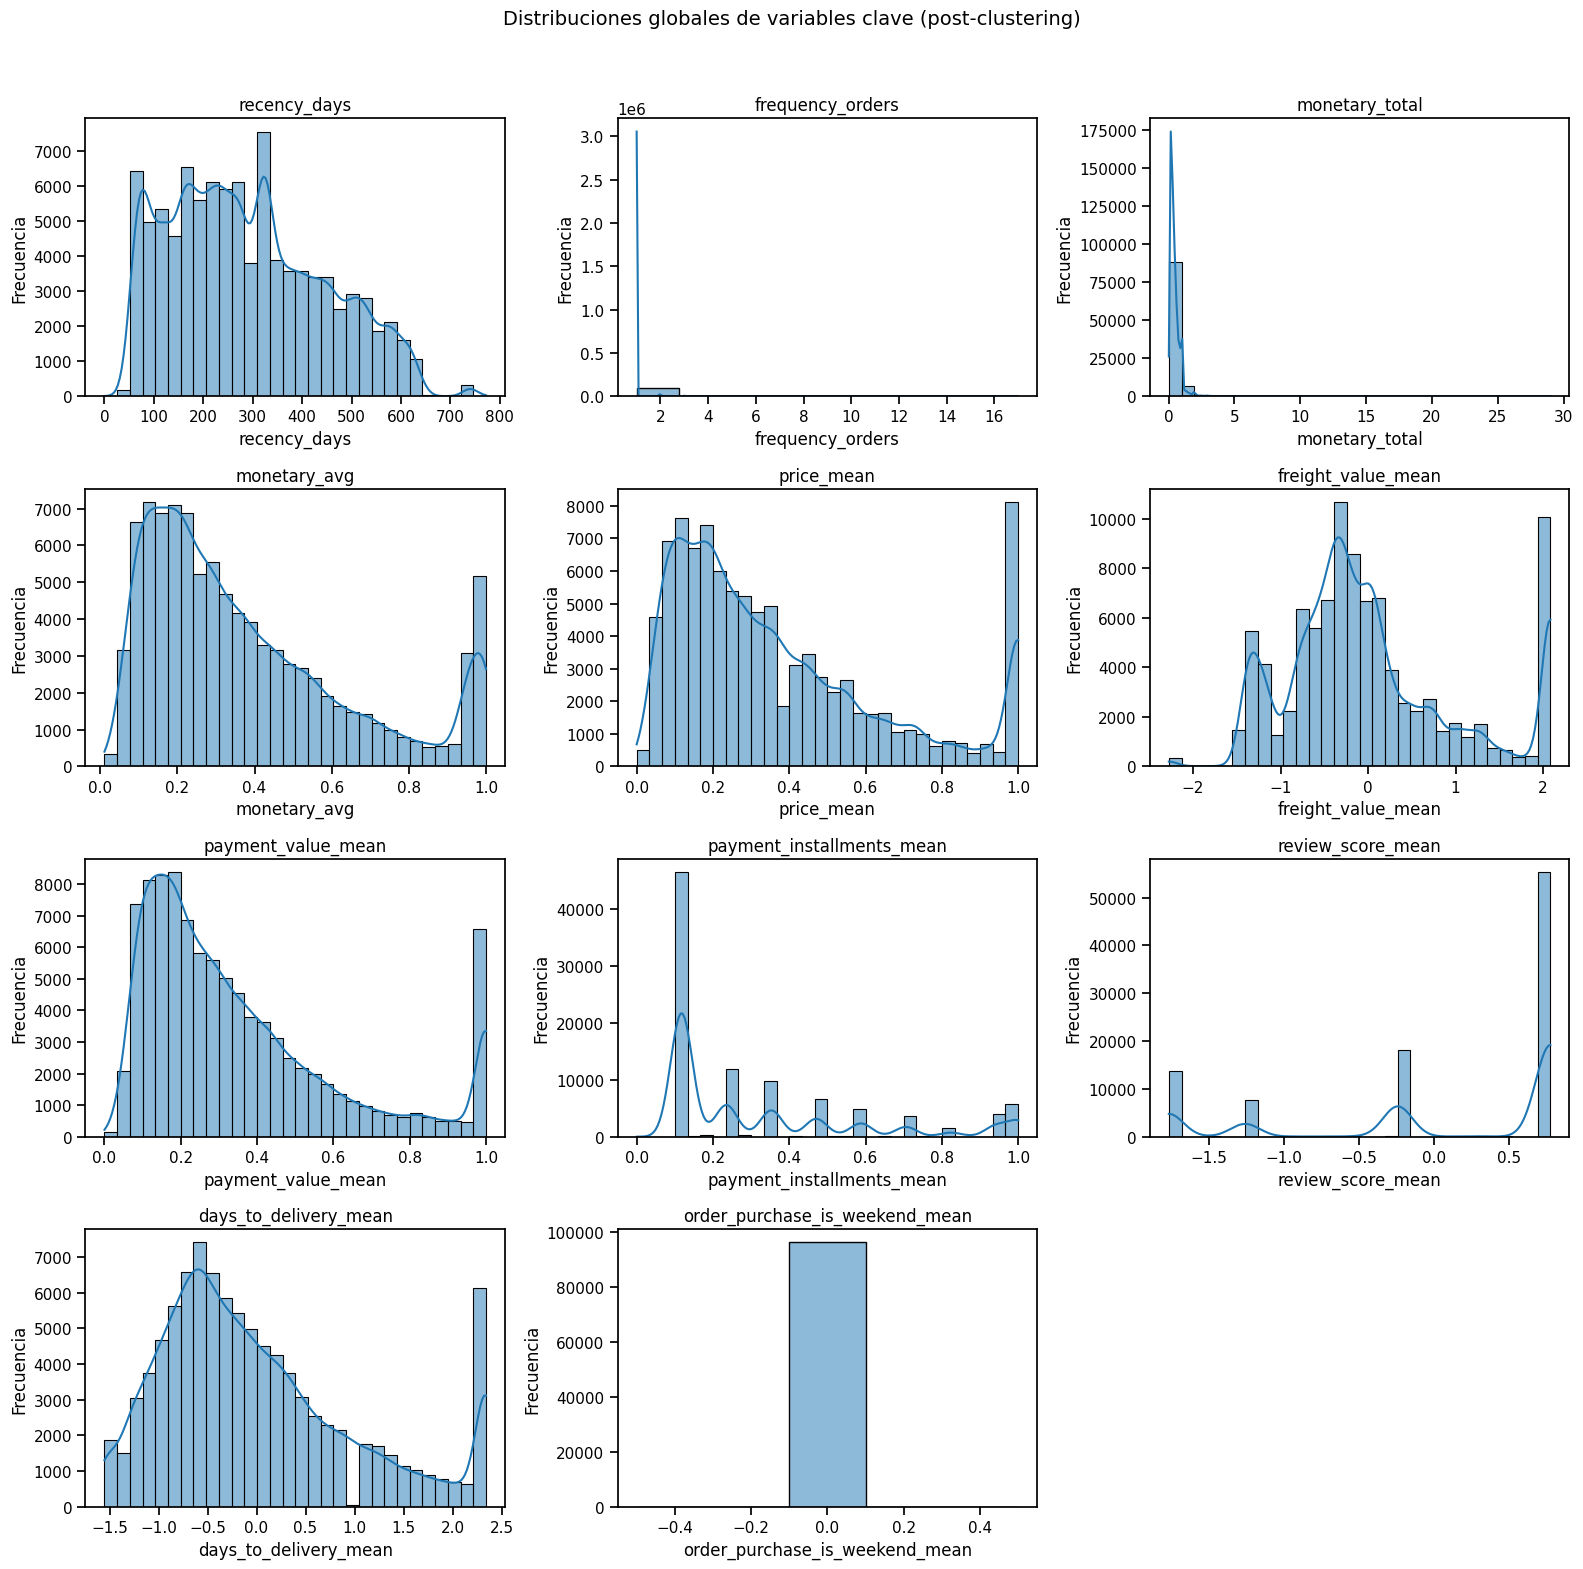

📌 Gráfico guardado en: C:\Users\goku8\OneDrive\Escritorio\MCHL - copiaaaaa\MLY0100-Parcial-1\notebooks\data\08_reporting\eda_post_clustering_distributions.png


In [17]:
# =========================================
# 5.1 Distribuciones globales de variables clave (post-clustering)
# =========================================
# Objetivo:
# - Analizar la distribución global de variables numéricas relevantes
# - Paso previo a la comparación por cluster (5.2)

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# 5.1.1 Validación de dataset EDA
# -----------------------------
if "df_eda" not in globals():
    print("⚠️ df_eda no existe. Se crea automáticamente desde df_clusters.")
    
    if "num_cols_features" not in globals():
        raise ValueError(
            "❌ num_cols_features no está definido. "
            "Ejecuta la Sección 4.3 antes de continuar."
        )
    
    df_eda = df_clusters[["cluster"] + num_cols_features].copy()

print("✅ df_eda listo:", df_eda.shape)

# -----------------------------
# 5.1.2 Definición de variables clave
# -----------------------------
key_features = [
    "recency_days",
    "frequency_orders",
    "monetary_total",
    "monetary_avg",
    "price_mean",
    "freight_value_mean",
    "payment_value_mean",
    "payment_installments_mean",
    "review_score_mean",
    "days_to_delivery_mean",
    "order_purchase_is_weekend_mean",
]

# Filtrar solo columnas realmente disponibles
key_features = [c for c in key_features if c in df_eda.columns]

if len(key_features) == 0:
    raise ValueError(
        "❌ No hay variables clave disponibles para EDA.\n"
        "Revisa los nombres de columnas o la Sección 4.3."
    )

print("📊 Variables clave para EDA global:")
for c in key_features:
    print(" -", c)

# -----------------------------
# 5.1.3 Visualización: distribuciones globales
# -----------------------------
n = len(key_features)
ncols = 3
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(16, 4 * nrows))
axes = np.array(axes).reshape(-1)

for i, col in enumerate(key_features):
    nunique = df_eda[col].nunique(dropna=True)
    bins = 30 if nunique > 20 else max(5, nunique)

    sns.histplot(df_eda[col], bins=bins, kde=True, ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frecuencia")

# Apagar subplots sobrantes
for j in range(i + 1, len(axes)):
    axes[j].axis("off")

fig.suptitle(
    "Distribuciones globales de variables clave (post-clustering)",
    fontsize=14
)
plt.tight_layout(rect=[0, 0, 1, 0.96])

# -----------------------------
# 5.1.4 Guardado
# -----------------------------
out_path = REPORT_DIR / "eda_post_clustering_distributions.png"
plt.savefig(out_path, dpi=150)
plt.show()

print("📌 Gráfico guardado en:", out_path)

## 5.2 Matriz de correlación (global)
Permite detectar variables redundantes o muy asociadas.

✅ Columnas usadas para correlación: ['recency_days', 'frequency_orders', 'monetary_total', 'monetary_avg', 'price_mean', 'freight_value_mean', 'payment_value_mean', 'payment_installments_mean', 'review_score_mean', 'days_to_delivery_mean', 'order_purchase_is_weekend_mean']


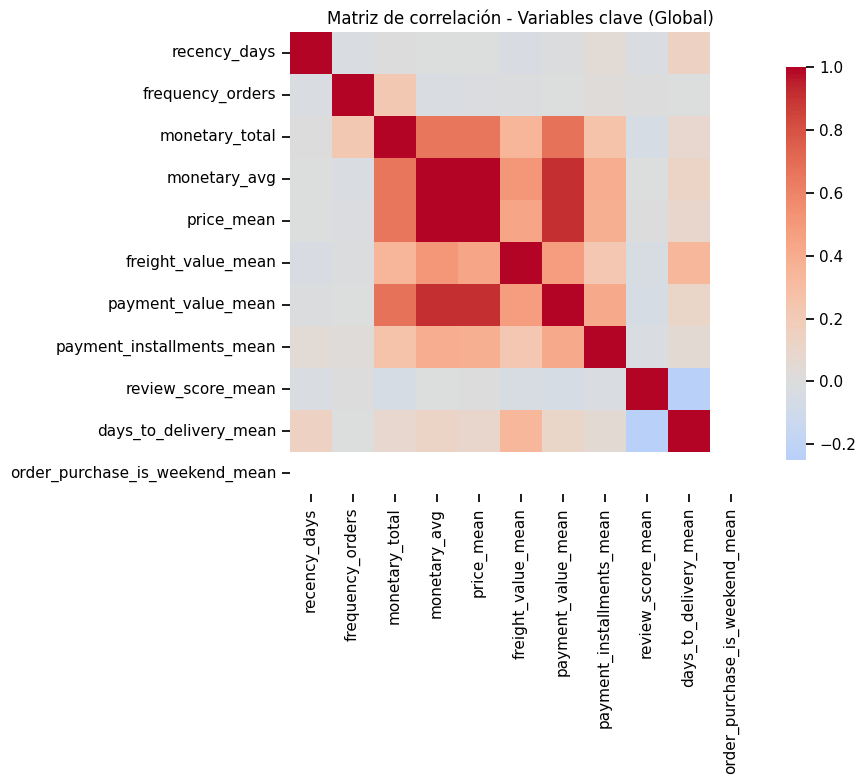

📌 Guardado: C:\Users\goku8\OneDrive\Escritorio\MCHL - copiaaaaa\MLY0100-Parcial-1\notebooks\data\08_reporting\eda_post_clustering_corr_heatmap.png


In [18]:

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1) Validaciones
if "df_eda" not in globals():
    raise ValueError("❌ df_eda no está definido. Ejecuta 4.3 (o 5.1) antes de este bloque.")

if "key_features" not in globals():
    # fallback: usa todas las features numéricas disponibles (sin cluster)
    print("⚠️ key_features no existe. Usando todas las columnas numéricas (sin cluster).")
    key_features = df_eda.select_dtypes(include=[np.number]).columns.tolist()
    key_features = [c for c in key_features if c != "cluster"]

# 2) Asegurar columnas existentes y numéricas
corr_cols = [c for c in key_features if c in df_eda.columns]
corr_cols = [c for c in corr_cols if pd.api.types.is_numeric_dtype(df_eda[c])]

if len(corr_cols) < 2:
    raise ValueError(
        f"❌ No hay suficientes columnas numéricas para correlación (se necesitan >=2). "
        f"Encontradas: {corr_cols}"
    )

print("✅ Columnas usadas para correlación:", corr_cols)

# 3) Calcular correlación
corr = df_eda[corr_cols].corr(numeric_only=True)

# 4) Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    annot=False,
    square=True,
    cbar_kws={"shrink": 0.85}
)
plt.title("Matriz de correlación - Variables clave (Global)")
plt.tight_layout()

out_path = REPORT_DIR / "eda_post_clustering_corr_heatmap.png"
plt.savefig(out_path, dpi=150)
plt.show()

print("📌 Guardado:", out_path)

## 6.1 Tamaños de cluster (distribución)
Validación visual de cuántos clientes hay en cada cluster.

cluster
0    23710
1     2981
2    37035
3    13858
4    18512
Name: count, dtype: int64

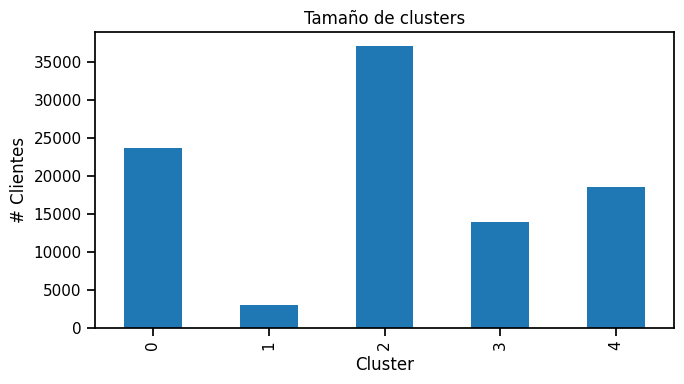

📌 Guardado: C:\Users\goku8\OneDrive\Escritorio\MCHL - copiaaaaa\MLY0100-Parcial-1\notebooks\data\08_reporting\eda_post_clustering_cluster_sizes.png


In [19]:
sizes = df_clusters['cluster'].value_counts().sort_index()
display(sizes)

plt.figure(figsize=(7, 4))
sizes.plot(kind='bar')
plt.title('Tamaño de clusters')
plt.xlabel('Cluster')
plt.ylabel('# Clientes')
plt.tight_layout()
out_path = REPORT_DIR / 'eda_post_clustering_cluster_sizes.png'
plt.savefig(out_path, dpi=150)
plt.show()
print('📌 Guardado:', out_path)


## 6.2 Perfilado por cluster (media y mediana)
Tabla base para interpretación de negocio.

In [20]:

import os
import numpy as np
import pandas as pd

# 1) Validaciones mínimas
if "cluster" not in df_clusters.columns:
    raise ValueError("❌ No existe la columna 'cluster' en df_clusters.")

# Si no existe num_cols_features, lo reconstruimos (fallback)
if "num_cols_features" not in globals():
    print("⚠️ num_cols_features no existe. Se reconstruye desde columnas numéricas.")
    num_cols = df_clusters.select_dtypes(include=[np.number]).columns.tolist()
    num_cols_features = [c for c in num_cols if c not in {"cluster", "customer_row_id", "customer_unique_id"}]

# 2) Asegurar que las columnas existan (por si cambió algo)
num_cols_features = [c for c in num_cols_features if c in df_clusters.columns]

if len(num_cols_features) == 0:
    raise ValueError("❌ No hay columnas numéricas para perfilar. Revisa 4.3.")

# 3) Calcular perfiles
profile_mean = df_clusters.groupby("cluster")[num_cols_features].mean(numeric_only=True)
profile_median = df_clusters.groupby("cluster")[num_cols_features].median(numeric_only=True)

print("📌 Perfilado (MEDIA) por cluster:")
if "key_features" in globals() and len([c for c in key_features if c in profile_mean.columns]) > 0:
    cols_show = [c for c in key_features if c in profile_mean.columns]
    display(profile_mean[cols_show])
else:
    display(profile_mean)

print("📌 Perfilado (MEDIANA) por cluster:")
if "key_features" in globals() and len([c for c in key_features if c in profile_median.columns]) > 0:
    cols_show = [c for c in key_features if c in profile_median.columns]
    display(profile_median[cols_show])
else:
    display(profile_median)

# 4) Guardado (entregables)
# OUTPUT_DIR puede ser string o Path; lo normalizamos
if "OUTPUT_DIR" in globals():
    out_dir = OUTPUT_DIR
    try:
        # si es Path
        out_dir = str(out_dir)
    except:
        pass
else:
    out_dir = "data/07_model_output"

os.makedirs(out_dir, exist_ok=True)

mean_path = os.path.join(out_dir, "cluster_profiles_mean.csv")
median_path = os.path.join(out_dir, "cluster_profiles_median.csv")

profile_mean.to_csv(mean_path)
profile_median.to_csv(median_path)

print("💾 Guardado:", mean_path)
print("💾 Guardado:", median_path)

📌 Perfilado (MEDIA) por cluster:


C:\Users\goku8\AppData\Local\Temp\ipykernel_22176\2953204728.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  profile_mean = df_clusters.groupby("cluster")[num_cols_features].mean(numeric_only=True)
C:\Users\goku8\AppData\Local\Temp\ipykernel_22176\2953204728.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  profile_median = df_clusters.groupby("cluster")[num_cols_features].median(numeric_only=True)


,recency_days,frequency_orders,monetary_total,monetary_avg,price_mean,freight_value_mean,payment_value_mean,payment_installments_mean,review_score_mean,days_to_delivery_mean,order_purchase_is_weekend_mean
cluster,,,,,,,,,,,
0,277.179882,1.000000,0.529761,0.475646,0.460012,0.479168,0.415458,0.410675,0.456542,0.027568,0.0
1,267.821201,2.116739,0.980558,0.347885,0.335633,-0.069980,0.340814,0.366777,0.070487,-0.017837,0.0
2,283.326448,1.000000,0.212524,0.190936,0.177172,-0.552192,0.173361,0.209391,0.540632,-0.377087,0.0
3,294.460312,1.001155,1.064617,0.889083,0.901988,0.916421,0.849294,0.568665,-0.057301,0.220639,0.0
4,308.249406,1.000000,0.319097,0.267953,0.248565,-0.085776,0.257855,0.281016,-1.403992,0.589707,0.0


📌 Perfilado (MEDIANA) por cluster:


,recency_days,frequency_orders,monetary_total,monetary_avg,price_mean,freight_value_mean,payment_value_mean,payment_installments_mean,review_score_mean,days_to_delivery_mean,order_purchase_is_weekend_mean
cluster,,,,,,,,,,,
0,257.0,1.0,0.502086,0.471419,0.453975,0.197465,0.405264,0.352941,0.779134,-0.185894,0.0
1,248.0,2.0,0.768800,0.296908,0.280944,-0.196543,0.281464,0.264706,0.269547,-0.185894,0.0
2,267.0,1.0,0.193154,0.178732,0.162885,-0.503643,0.161802,0.117647,0.779134,-0.459091,0.0
3,275.0,1.0,0.965601,0.952699,1.000000,0.866151,0.919168,0.588235,0.779134,-0.049295,0.0
4,284.0,1.0,0.287417,0.247091,0.218189,-0.209151,0.228403,0.117647,-1.768799,0.497098,0.0


💾 Guardado: data/07_model_output\cluster_profiles_mean.csv
💾 Guardado: data/07_model_output\cluster_profiles_median.csv


## 6.3 Boxplots por cluster (detección de outliers y diferencias)
Se comparan distribuciones por cluster para variables clave.

📊 Variables usadas para boxplots:
 - recency_days
 - frequency_orders
 - monetary_total
 - monetary_avg
 - price_mean
 - freight_value_mean
 - payment_value_mean
 - payment_installments_mean
 - review_score_mean
 - days_to_delivery_mean
 - order_purchase_is_weekend_mean


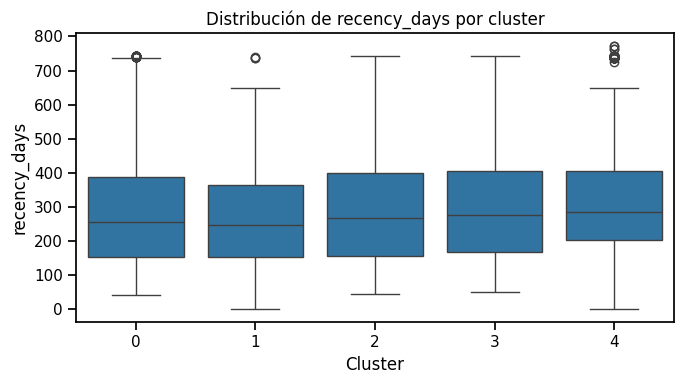

💾 Guardado: C:\Users\goku8\OneDrive\Escritorio\MCHL - copiaaaaa\MLY0100-Parcial-1\notebooks\data\08_reporting\boxplots_by_cluster\boxplot_recency_days_by_cluster.png


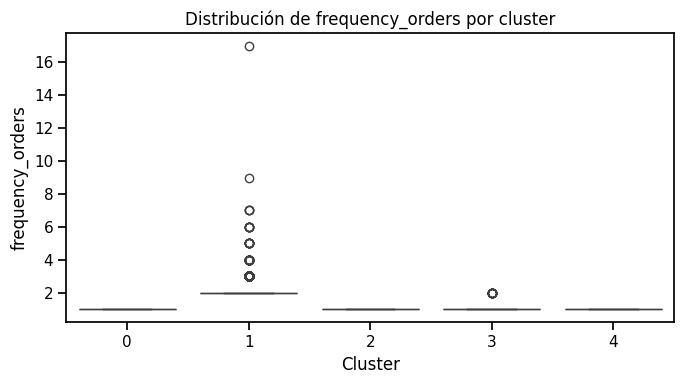

💾 Guardado: C:\Users\goku8\OneDrive\Escritorio\MCHL - copiaaaaa\MLY0100-Parcial-1\notebooks\data\08_reporting\boxplots_by_cluster\boxplot_frequency_orders_by_cluster.png


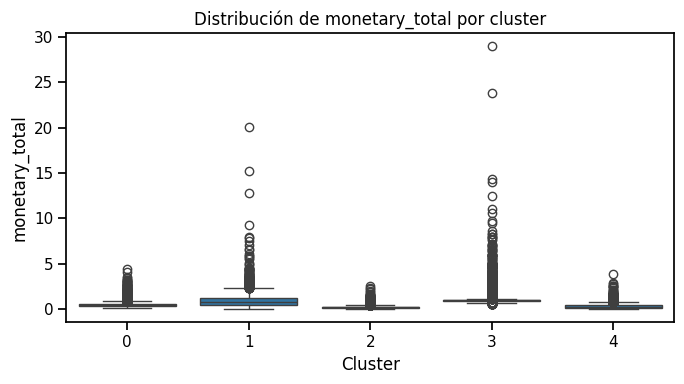

💾 Guardado: C:\Users\goku8\OneDrive\Escritorio\MCHL - copiaaaaa\MLY0100-Parcial-1\notebooks\data\08_reporting\boxplots_by_cluster\boxplot_monetary_total_by_cluster.png


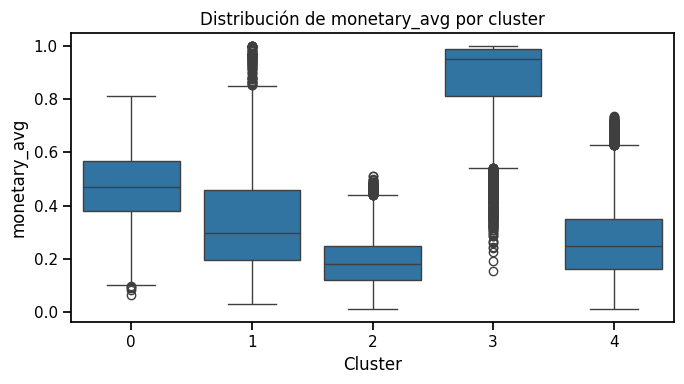

💾 Guardado: C:\Users\goku8\OneDrive\Escritorio\MCHL - copiaaaaa\MLY0100-Parcial-1\notebooks\data\08_reporting\boxplots_by_cluster\boxplot_monetary_avg_by_cluster.png


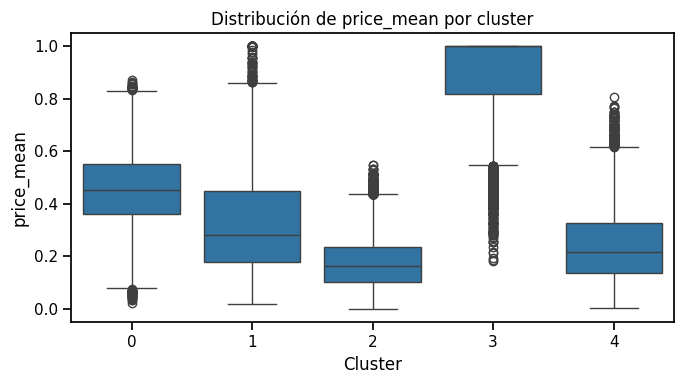

💾 Guardado: C:\Users\goku8\OneDrive\Escritorio\MCHL - copiaaaaa\MLY0100-Parcial-1\notebooks\data\08_reporting\boxplots_by_cluster\boxplot_price_mean_by_cluster.png


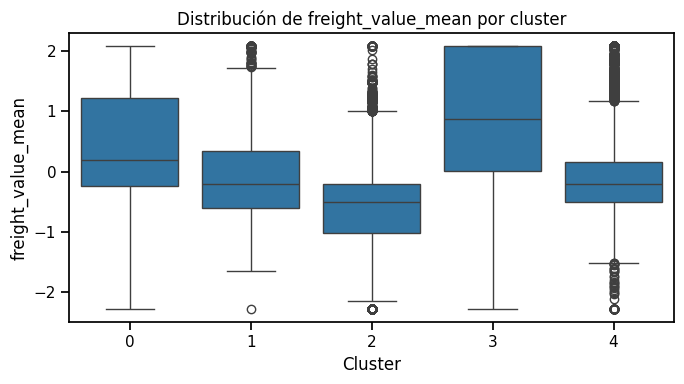

💾 Guardado: C:\Users\goku8\OneDrive\Escritorio\MCHL - copiaaaaa\MLY0100-Parcial-1\notebooks\data\08_reporting\boxplots_by_cluster\boxplot_freight_value_mean_by_cluster.png


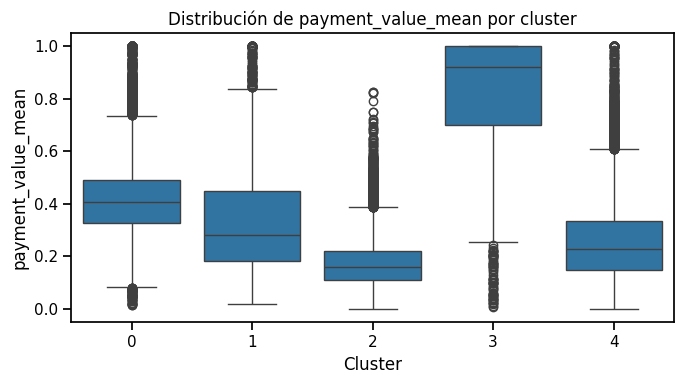

💾 Guardado: C:\Users\goku8\OneDrive\Escritorio\MCHL - copiaaaaa\MLY0100-Parcial-1\notebooks\data\08_reporting\boxplots_by_cluster\boxplot_payment_value_mean_by_cluster.png


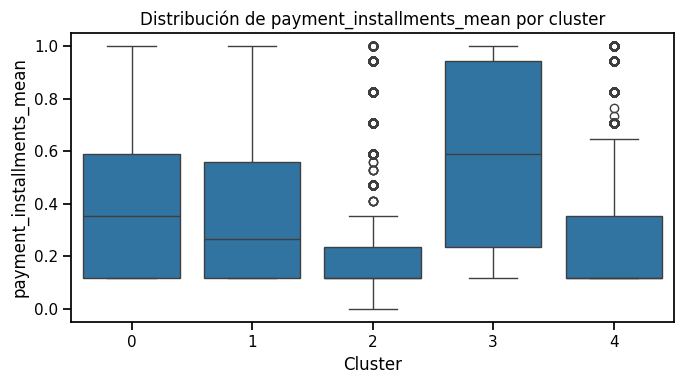

💾 Guardado: C:\Users\goku8\OneDrive\Escritorio\MCHL - copiaaaaa\MLY0100-Parcial-1\notebooks\data\08_reporting\boxplots_by_cluster\boxplot_payment_installments_mean_by_cluster.png


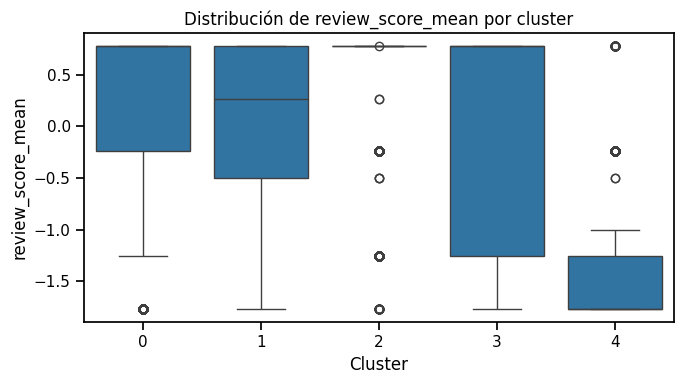

💾 Guardado: C:\Users\goku8\OneDrive\Escritorio\MCHL - copiaaaaa\MLY0100-Parcial-1\notebooks\data\08_reporting\boxplots_by_cluster\boxplot_review_score_mean_by_cluster.png


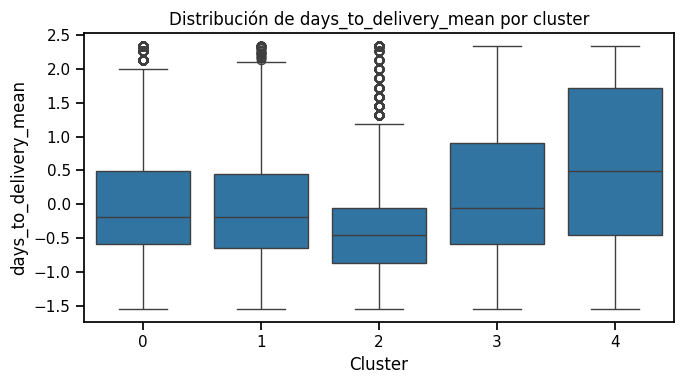

💾 Guardado: C:\Users\goku8\OneDrive\Escritorio\MCHL - copiaaaaa\MLY0100-Parcial-1\notebooks\data\08_reporting\boxplots_by_cluster\boxplot_days_to_delivery_mean_by_cluster.png


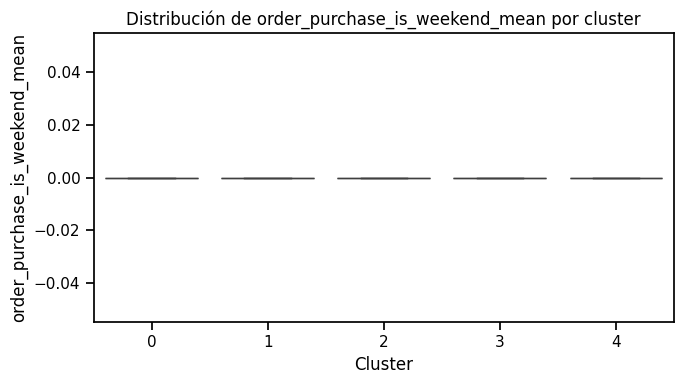

💾 Guardado: C:\Users\goku8\OneDrive\Escritorio\MCHL - copiaaaaa\MLY0100-Parcial-1\notebooks\data\08_reporting\boxplots_by_cluster\boxplot_order_purchase_is_weekend_mean_by_cluster.png
✅ Boxplots por cluster generados correctamente.


In [21]:

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

# -----------------------------
# 6.3.1 Validaciones
# -----------------------------
if "df_clusters" not in globals():
    raise ValueError("❌ df_clusters no está definido.")

if "cluster" not in df_clusters.columns:
    raise ValueError("❌ No existe la columna 'cluster'.")

# Variables a graficar
if "key_features" in globals() and len(key_features) > 0:
    to_plot = [c for c in key_features if c in df_clusters.columns]
else:
    print("⚠️ key_features no disponible. Usando num_cols_features.")
    to_plot = [c for c in num_cols_features if c in df_clusters.columns]

if len(to_plot) == 0:
    raise ValueError("❌ No hay variables disponibles para boxplots.")

print("📊 Variables usadas para boxplots:")
for c in to_plot:
    print(" -", c)

# -----------------------------
# 6.3.2 Generar boxplots (uno por variable)
# -----------------------------
boxplot_dir = REPORT_DIR / "boxplots_by_cluster"
boxplot_dir.mkdir(exist_ok=True, parents=True)

for col in to_plot:
    plt.figure(figsize=(7, 4))
    sns.boxplot(
        data=df_clusters,
        x="cluster",
        y=col,
        showfliers=True
    )
    plt.title(f"Distribución de {col} por cluster")
    plt.xlabel("Cluster")
    plt.ylabel(col)
    plt.tight_layout()

    out_path = boxplot_dir / f"boxplot_{col}_by_cluster.png"
    plt.savefig(out_path, dpi=150)
    plt.show()

    print("💾 Guardado:", out_path)

print("✅ Boxplots por cluster generados correctamente.")

## 6.4 Comparación relativa vs promedio global
Valores >1 indican que el cluster está por sobre el promedio global en esa variable.

In [22]:

import numpy as np
import pandas as pd

# -----------------------------
# 6.4.1 Validaciones
# -----------------------------
if "df_clusters" not in globals():
    raise ValueError("❌ df_clusters no está definido.")
if "cluster" not in df_clusters.columns:
    raise ValueError("❌ No existe la columna 'cluster'.")
if "num_cols_features" not in globals() or len(num_cols_features) == 0:
    raise ValueError("❌ num_cols_features no existe o está vacío. Ejecuta 4.3.")

# Asegurar columnas existentes
cols = [c for c in num_cols_features if c in df_clusters.columns]
if len(cols) == 0:
    raise ValueError("❌ No hay columnas numéricas válidas para comparar vs global.")

# -----------------------------
# 6.4.2 Cálculo perfil relativo
# -----------------------------
overall_mean = df_clusters[cols].mean(numeric_only=True).replace(0, np.nan)
profile_mean = df_clusters.groupby("cluster")[cols].mean(numeric_only=True)

profile_vs_global = profile_mean.divide(overall_mean, axis=1)

print("📌 Perfil relativo vs promedio global (>1 sobre promedio, <1 bajo promedio):")

# Mostrar solo variables clave si existen
if "key_features" in globals() and len([c for c in key_features if c in profile_vs_global.columns]) > 0:
    cols_show = [c for c in key_features if c in profile_vs_global.columns]
    display(profile_vs_global[cols_show])
else:
    display(profile_vs_global)

# -----------------------------
# 6.4.3 Guardado
# -----------------------------
# Guardar en model_output (misma lógica que 03_Clustering)
out_path = PROJECT_ROOT / "data/07_model_output/eda_cluster_profile_vs_global.csv"
profile_vs_global.to_csv(out_path)

print("💾 Guardado:", out_path)

📌 Perfil relativo vs promedio global (>1 sobre promedio, <1 bajo promedio):


C:\Users\goku8\AppData\Local\Temp\ipykernel_22176\2877225782.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  profile_mean = df_clusters.groupby("cluster")[cols].mean(numeric_only=True)


,recency_days,frequency_orders,monetary_total,monetary_avg,price_mean,freight_value_mean,payment_value_mean,payment_installments_mean,review_score_mean,days_to_delivery_mean,order_purchase_is_weekend_mean
cluster,,,,,,,,,,,
0,0.963314,0.966362,1.156602,1.246556,1.242764,25.384749,1.180138,1.246186,10.269038,4.347765,NaN
1,0.930789,2.045536,2.140805,0.911725,0.906744,-3.707306,0.968106,1.112979,1.585461,-2.813074,NaN
2,0.984676,0.966362,0.463993,0.500397,0.478647,-29.253304,0.492445,0.635393,12.160466,-59.470649,NaN
3,1.023371,0.967478,2.324326,2.330077,2.436801,48.548979,2.412479,1.725605,-1.288873,34.797093,NaN
4,1.071294,0.966362,0.696669,0.702241,0.671520,-4.544111,0.732454,0.852740,-31.580100,93.003113,NaN


💾 Guardado: C:\Users\goku8\OneDrive\Escritorio\MCHL - copiaaaaa\MLY0100-Parcial-1\notebooks\data\07_model_output\eda_cluster_profile_vs_global.csv


# FASE 5: EVALUATION (Interpretación y recomendaciones)

## 7.1 Guía de interpretación por cluster
Usa las tablas anteriores (perfilado y perfil relativo) para redactar esta sección.

Plantilla sugerida (por cluster):
- **Cluster X**: descripción basada en recency/frequency/monetary/logística/satisfacción.
- **Riesgos**: (si aplica) alta recency, baja frecuencia, baja satisfacción.
- **Acciones sugeridas**: retención, activación, mejoras logísticas, etc.


## 7.2 Insights rápidos (auto-generados)
Este bloque calcula un resumen textual simple (útil como borrador para tu narrativa).

In [23]:

import numpy as np
import pandas as pd


# Validaciones

if "profile_mean" not in globals():
    raise ValueError("❌ profile_mean no existe. Ejecuta la Sección 6.2.")

if "df_clusters" not in globals():
    raise ValueError("❌ df_clusters no está definido.")

# Construcción del resumen

summary_rows = []

for cl in sorted(df_clusters["cluster"].unique()):
    row = profile_mean.loc[cl]

    def g(col):
        return float(row[col]) if col in row.index else np.nan

    summary_rows.append({
        "cluster": int(cl),
        "n_clientes": int((df_clusters["cluster"] == cl).sum()),
        "recency_days_mean": g("recency_days"),
        "frequency_orders_mean": g("frequency_orders"),
        "monetary_total_mean": g("monetary_total"),
        "monetary_avg_mean": g("monetary_avg"),
        "review_score_mean": g("review_score_mean"),
        "days_to_delivery_mean": g("days_to_delivery_mean"),
    })

summary_df = pd.DataFrame(summary_rows)

display(summary_df)

# Guardado
out_path = PROJECT_ROOT / "data/07_model_output/eda_cluster_quick_summary.csv"
summary_df.to_csv(out_path, index=False)

print("💾 Guardado:", out_path)

,cluster,n_clientes,recency_days_mean,frequency_orders_mean,monetary_total_mean,monetary_avg_mean,review_score_mean,days_to_delivery_mean
0,0,23710,277.179882,1.000000,0.529761,0.475646,0.456542,0.027568
1,1,2981,267.821201,2.116739,0.980558,0.347885,0.070487,-0.017837
2,2,37035,283.326448,1.000000,0.212524,0.190936,0.540632,-0.377087
3,3,13858,294.460312,1.001155,1.064617,0.889083,-0.057301,0.220639
4,4,18512,308.249406,1.000000,0.319097,0.267953,-1.403992,0.589707


💾 Guardado: C:\Users\goku8\OneDrive\Escritorio\MCHL - copiaaaaa\MLY0100-Parcial-1\notebooks\data\07_model_output\eda_cluster_quick_summary.csv


# FASE 6: DEPLOYMENT (Entregables)

## 8.1 Evidencias generadas

Durante el EDA post-clustering se generaron los siguientes entregables:

- **Distribuciones globales** de variables clave  
  `data/08_reporting/eda_post_clustering_distributions.png`

- **Matriz de correlación global**  
  `data/08_reporting/eda_post_clustering_corr_heatmap.png`

- **Distribución de clientes por cluster**  
  `data/08_reporting/eda_post_clustering_cluster_sizes.png`

- **Boxplots por cluster** (outliers y diferencias)  
  `data/08_reporting/boxplots_by_cluster/`

- **Perfil relativo vs promedio global**  
  `data/07_model_output/eda_cluster_profile_vs_global.csv`

- **Resumen cuantitativo por cluster**  
  `data/07_model_output/eda_cluster_quick_summary.csv`

Estos artefactos permiten validar, interpretar y reutilizar los resultados del clustering.


## 8.2 Conclusiones

El análisis post-clustering evidencia **segmentos de clientes claramente diferenciados**
en términos de valor, frecuencia de compra, comportamiento temporal y experiencia.

- Se identifican clusters de **alto valor económico**, con gasto y ticket promedio
superiores al promedio global.
- Otros clusters presentan **comportamiento ocasional** y bajo gasto, con potencial
de activación.
- Variables logísticas y de satisfacción aportan información complementaria y explican
diferencias entre segmentos.

Estos resultados permiten definir **estrategias diferenciadas de retención, activación
y optimización operativa**, y constituyen una base sólida para decisiones comerciales
y analíticas futuras.